# Лабораторная работа 2. Fine-tuning ResNet-34 на Fashion MNIST




## 1. Импорты



In [1]:
%matplotlib inline

import os
import random
from pathlib import Path

os.environ.setdefault("NO_ALBUMENTATIONS_UPDATE", "1")

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet34_Weights, resnet34



## 2. Гиперпараметры



In [2]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = 28
INPUT_SIZE = 224
FASHION_MEAN = 0.2860
FASHION_STD = 0.3530

BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
HEAD_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
ADAM_BETAS = (0.9, 0.999)
ETA_MIN = 1e-6
WARMUP_EPOCHS = 2
GRAD_CLIP_NORM = 1.0
VAL_SIZE = 0.1
SEED = 42
NUM_WORKERS = 2
CPU_THREADS = min(8, os.cpu_count() or 8)
USE_FOCAL_LOSS = False
FREEZE_BACKBONE = False
USE_AMP = True



## 3. Устройство, seed и служебные функции



In [3]:
def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content"), Path("/content/data").parent]
    try:
        candidates.insert(0, Path(__file__).resolve().parents[1])
    except NameError:
        pass

    seen = []
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.append(candidate)
        if (candidate / "data" / "fashion-mnist_train.csv").exists():
            return candidate
        if (candidate / "fashion-mnist_train.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Не найден каталог data с файлами fashion-mnist_train.csv / fashion-mnist_test.csv"
    )


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def configure_runtime() -> torch.device:
    device = get_device()
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        torch.set_num_threads(CPU_THREADS)
        try:
            torch.set_num_interop_threads(1)
        except RuntimeError:
            pass
        print("GPU не найдена, обучение будет медленным. В Colab выберите Runtime → T4 GPU.")
    return device


def amp_enabled(device: torch.device) -> bool:
    return bool(USE_AMP and device.type == "cuda")


def autocast_ctx(device: torch.device):
    return torch.autocast(device_type=device.type, enabled=amp_enabled(device))


def make_grad_scaler(device: torch.device):
    return torch.cuda.amp.GradScaler(enabled=amp_enabled(device))


def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad or not trainable_only)



## 4. Адаптация предобученного ResNet-34


In [4]:
def build_resnet34(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=FREEZE_BACKBONE):
    weights = ResNet34_Weights.DEFAULT if pretrained else None
    model = resnet34(weights=weights)

    original_conv1 = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=original_conv1.out_channels,
        kernel_size=original_conv1.kernel_size,
        stride=original_conv1.stride,
        padding=original_conv1.padding,
        bias=False,
    )
    with torch.no_grad():
        if pretrained:
            model.conv1.weight.copy_(original_conv1.weight.mean(dim=1, keepdim=True))
        else:
            nn.init.kaiming_normal_(model.conv1.weight, mode="fan_out", nonlinearity="relu")

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if freeze_backbone:
        for name, param in model.named_parameters():
            param.requires_grad = name.startswith("fc") or name.startswith("conv1")

    return model


with torch.no_grad():
    _check_model = build_resnet34(pretrained=False).eval()
    _check = _check_model(torch.randn(2, 1, INPUT_SIZE, INPUT_SIZE))
print("Проверка forward:", tuple(_check.shape))
print("Параметров:", f"{count_parameters(_check_model):,}")
del _check_model



Проверка forward: (2, 10)
Параметров: 21,283,530


## 5. Данные Fashion MNIST



In [5]:
def get_train_transforms():
    return A.Compose(
        [
            A.Resize(INPUT_SIZE, INPUT_SIZE),
            A.HorizontalFlip(p=0.5),
            A.Affine(translate_percent=0.06, scale=(0.9, 1.1), rotate=(-12, 12), p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.15, p=0.3),
            A.CoarseDropout(
                num_holes_range=(1, 2),
                hole_height_range=(16, 32),
                hole_width_range=(16, 32),
                p=0.25,
            ),
            A.Normalize(mean=FASHION_MEAN, std=FASHION_STD),
            ToTensorV2(),
        ]
    )


def get_eval_transforms():
    return A.Compose(
        [
            A.Resize(INPUT_SIZE, INPUT_SIZE),
            A.Normalize(mean=FASHION_MEAN, std=FASHION_STD),
            ToTensorV2(),
        ]
    )



In [6]:
class FashionMNISTDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        self.features = np.asarray(features, dtype=np.uint8).reshape(-1, IMAGE_SIZE, IMAGE_SIZE)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        image = self.features[index]
        label = self.labels[index]
        if self.transform is not None:
            image = self.transform(image=image)["image"]
        else:
            image = torch.from_numpy(image).unsqueeze(0).float() / 255.0
        return image, label


def load_csv_xy(csv_path: Path):
    df = pd.read_csv(csv_path)
    return df.iloc[:, 1:].to_numpy(), df.iloc[:, 0].to_numpy()


def create_dataloaders(data_dir: Path, batch_size=BATCH_SIZE, val_size=VAL_SIZE, num_workers=NUM_WORKERS):
    train_features, train_labels = load_csv_xy(data_dir / "fashion-mnist_train.csv")
    test_features, test_labels = load_csv_xy(data_dir / "fashion-mnist_test.csv")
    x_train, x_val, y_train, y_val = train_test_split(
        train_features, train_labels, test_size=val_size, random_state=SEED, stratify=train_labels
    )

    train_dataset = FashionMNISTDataset(x_train, y_train, transform=get_train_transforms())
    val_dataset = FashionMNISTDataset(x_val, y_val, transform=get_eval_transforms())
    test_dataset = FashionMNISTDataset(test_features, test_labels, transform=get_eval_transforms())

    pin_memory = torch.cuda.is_available()
    workers = num_workers if pin_memory else 0
    common = dict(batch_size=batch_size, num_workers=workers, pin_memory=pin_memory)
    if workers > 0:
        common["persistent_workers"] = True
        common["prefetch_factor"] = 2
    train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True, **common)
    val_loader = DataLoader(val_dataset, shuffle=False, **common)
    test_loader = DataLoader(test_dataset, shuffle=False, **common)
    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset



GPU: Tesla T4
CUDA memory: 15.6 GB
Device: cuda
AMP: True
Input size: 224, batch: 64, epochs: 15
CPU threads: 1
Data dir: /content/data
Train: (2365, 784) Test: (2357, 784)


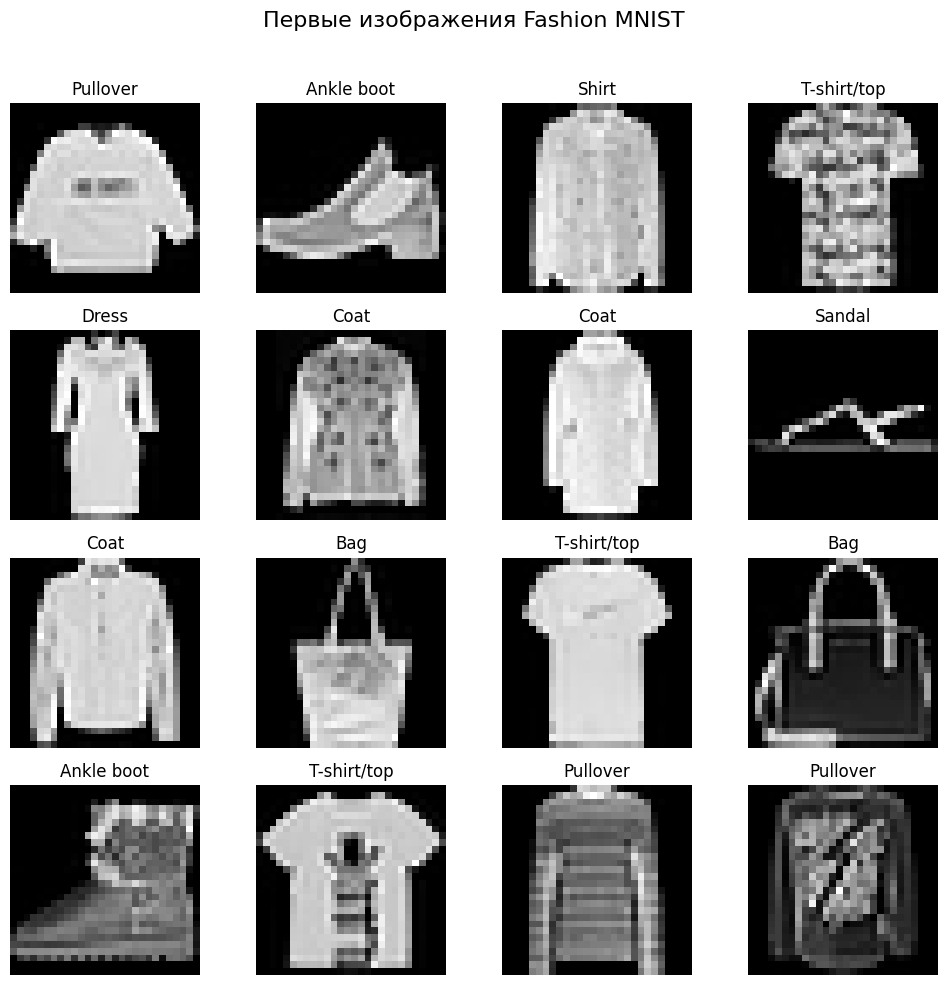

In [7]:
def show_sample_images(features, labels, n=16, title="Первые изображения Fashion MNIST"):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes.flat[:n]):
        ax.imshow(np.asarray(features[i]).reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray")
        ax.set_title(CLASS_NAMES[int(labels[i])])
        ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


set_seed(SEED)
ROOT = find_project_root()
DATA_DIR = ROOT / "data" if (ROOT / "data" / "fashion-mnist_train.csv").exists() else ROOT
DEVICE = configure_runtime()
print(f"Device: {DEVICE}")
print(f"AMP: {amp_enabled(DEVICE)}")
print(f"Input size: {INPUT_SIZE}, batch: {BATCH_SIZE}, epochs: {NUM_EPOCHS}")
print(f"CPU threads: {torch.get_num_threads()}")
print(f"Data dir: {DATA_DIR}")

train_features, train_labels = load_csv_xy(DATA_DIR / "fashion-mnist_train.csv")
test_features, test_labels = load_csv_xy(DATA_DIR / "fashion-mnist_test.csv")
print("Train:", train_features.shape, "Test:", test_features.shape)
show_sample_images(train_features, train_labels)



In [8]:
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = create_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    val_size=VAL_SIZE,
    num_workers=NUM_WORKERS,
)
images, labels = next(iter(train_loader))
print("Батч:", tuple(images.shape), tuple(labels.shape))
print("Train / val / test:", len(train_dataset), len(val_dataset), len(test_dataset))



/tmp/ipykernel_421/1283483550.py:3: RuntimeWarning: invalid value encountered in cast
  self.features = np.asarray(features, dtype=np.uint8).reshape(-1, IMAGE_SIZE, IMAGE_SIZE)


Батч: (64, 1, 224, 224) (64,)
Train / val / test: 2128 237 2357


## 6. Функция потерь, AdamW и обучение



In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none")

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1.0 - pt) ** self.gamma * ce_loss).mean()


def make_criterion():
    if USE_FOCAL_LOSS:
        return FocalLoss()
    return nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def make_optimizer(model: nn.Module):
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("fc") or name.startswith("conv1"):
            head_params.append(param)
        else:
            backbone_params.append(param)

    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": LEARNING_RATE})
    if head_params:
        param_groups.append({"params": head_params, "lr": HEAD_LEARNING_RATE})
    return torch.optim.AdamW(
        param_groups,
        betas=ADAM_BETAS,
        weight_decay=WEIGHT_DECAY,
    )


def make_scheduler(optimizer):
    warmup_epochs = min(WARMUP_EPOCHS, max(NUM_EPOCHS - 1, 0))
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(NUM_EPOCHS - warmup_epochs, 1), eta_min=ETA_MIN
    )
    if warmup_epochs <= 0:
        return cosine
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=warmup_epochs
    )
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
    )


def maybe_tensorboard_writer(log_dir: Path):
    try:
        from torch.utils.tensorboard import SummaryWriter

        return SummaryWriter(log_dir=str(log_dir))
    except Exception:
        print("TensorBoard недоступен, кривые обучения будут построены через matplotlib.")
        return None



In [10]:
@torch.no_grad()
def run_eval_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast_ctx(device):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, writer=None, scheduler=None):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None
    scaler = make_grad_scaler(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast_ctx(device):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            if GRAD_CLIP_NORM:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = run_eval_epoch(model, val_loader, criterion, device)
        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if writer is not None:
            writer.add_scalar("Loss/train", train_loss, epoch + 1)
            writer.add_scalar("Loss/val", val_loss, epoch + 1)
            writer.add_scalar("Accuracy/train", train_acc, epoch + 1)
            writer.add_scalar("Accuracy/val", val_acc, epoch + 1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        current_lrs = ", ".join(f"{group['lr']:.2e}" for group in optimizer.param_groups)
        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}, lr: [{current_lrs}]"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Лучшая val_acc: {best_val_acc:.4f}")
    return history



In [11]:
model = build_resnet34(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=FREEZE_BACKBONE).to(DEVICE)
criterion = make_criterion()
optimizer = make_optimizer(model)
scheduler = make_scheduler(optimizer)
writer = maybe_tensorboard_writer(ROOT / "runs" / "fashion_mnist_resnet34")

print(model.conv1)
print(model.fc)
print(f"Всего параметров: {count_parameters(model):,}")
print(f"Обучаемых параметров: {count_parameters(model, trainable_only=True):,}")
print(f"AMP: {amp_enabled(DEVICE)}")
print(optimizer)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    DEVICE,
    num_epochs=NUM_EPOCHS,
    writer=writer,
    scheduler=scheduler,
)
weights_path = ROOT / "src" / "fashion_mnist_resnet34.pth"
weights_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), weights_path)
print(f"Модель сохранена: {weights_path}")



Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 178MB/s]


Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=10, bias=True)
Всего параметров: 21,283,530
Обучаемых параметров: 21,283,530
AMP: True
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 1e-05
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


/tmp/ipykernel_421/2877348837.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return torch.cuda.amp.GradScaler(enabled=amp_enabled(device))


Epoch 1/15 - train_loss: 1.9873, train_acc: 0.3717, val_loss: 1.9719, val_acc: 0.3502, lr: [5.50e-05, 5.50e-04]
Epoch 2/15 - train_loss: 0.9015, train_acc: 0.7718, val_loss: 0.8206, val_acc: 0.7679, lr: [1.00e-04, 1.00e-03]
Epoch 3/15 - train_loss: 0.6860, train_acc: 0.8438, val_loss: 0.8285, val_acc: 0.7848, lr: [9.86e-05, 9.85e-04]
Epoch 4/15 - train_loss: 0.6153, train_acc: 0.8802, val_loss: 0.7182, val_acc: 0.8270, lr: [9.43e-05, 9.43e-04]
Epoch 5/15 - train_loss: 0.5336, train_acc: 0.9034, val_loss: 0.6700, val_acc: 0.8523, lr: [8.76e-05, 8.74e-04]
Epoch 6/15 - train_loss: 0.4798, train_acc: 0.9318, val_loss: 0.5907, val_acc: 0.8776, lr: [7.86e-05, 7.84e-04]
Epoch 7/15 - train_loss: 0.4375, train_acc: 0.9446, val_loss: 0.6775, val_acc: 0.8481, lr: [6.81e-05, 6.78e-04]
Epoch 8/15 - train_loss: 0.4114, train_acc: 0.9588, val_loss: 0.5538, val_acc: 0.9072, lr: [5.65e-05, 5.61e-04]
Epoch 9/15 - train_loss: 0.3760, train_acc: 0.9740, val_loss: 0.5271, val_acc: 0.9325, lr: [4.45e-05, 4.

## 7. Оценка на тесте



In [12]:
@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for inputs, labels in dataloader:
        with autocast_ctx(device):
            outputs = model(inputs.to(device, non_blocking=True))
            probs = torch.softmax(outputs, dim=1)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)
    class_labels = list(range(NUM_CLASSES))
    try:
        roc_auc = roc_auc_score(
            y_true, y_prob, average="weighted", multi_class="ovr", labels=class_labels
        )
    except ValueError:
        roc_auc = float("nan")
    metrics = {
        "accuracy": (y_true == y_pred).mean(),
        "f1": f1_score(y_true, y_pred, average="weighted", labels=class_labels, zero_division=0),
        "roc_auc": roc_auc,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=class_labels),
    }
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print("Confusion Matrix:")
    print(metrics["confusion_matrix"])
    return metrics


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True)
    axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(True)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set_title("Confusion Matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()



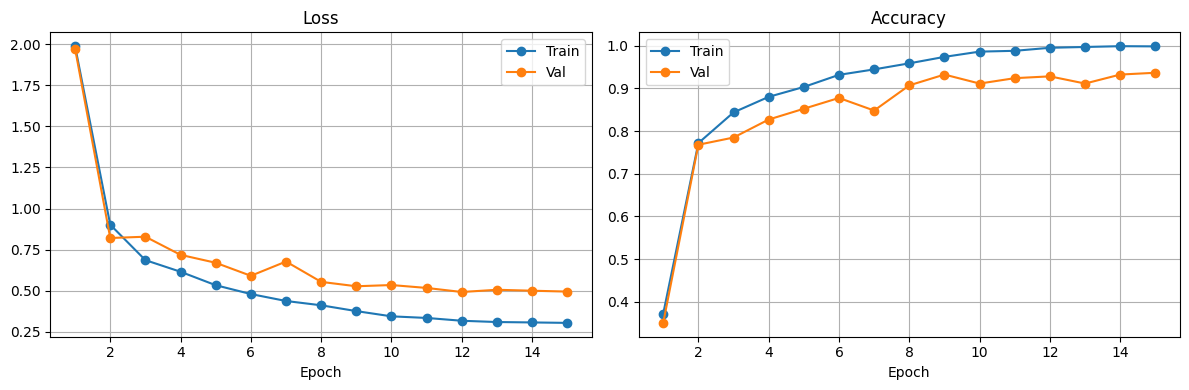

Accuracy: 0.9041
F1 Score: 0.9039
ROC-AUC: 0.9894
Confusion Matrix:
[[199   2   2   7   0   0  24   0   1   0]
 [  0 211   0   4   0   0   0   0   1   0]
 [  4   0 205   2  11   0  15   0   1   0]
 [  2   0   3 230   5   0   9   0   0   0]
 [  0   0   9   2 210   0  11   0   1   0]
 [  0   0   0   0   0 227   0   7   0   2]
 [ 25   2  16   2  18   0 184   0   3   0]
 [  0   0   0   0   0   2   0 217   0  13]
 [  0   0   1   0   2   1   1   0 224   0]
 [  0   0   0   0   0   2   0  13   0 224]]


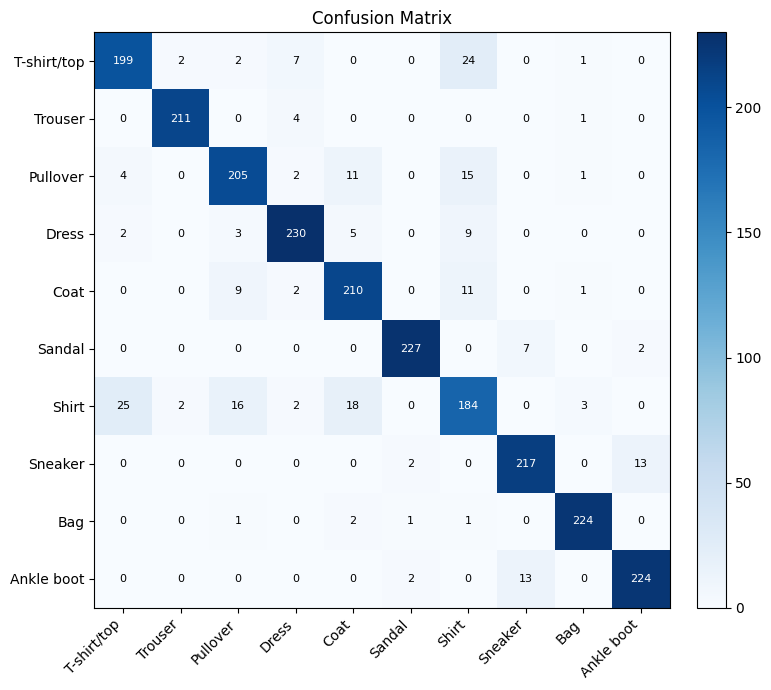

In [13]:
plot_history(history)
metrics = evaluate_model(model, test_loader, DEVICE)
plot_confusion_matrix(metrics["confusion_matrix"])



## 8. Предсказания и Grad-CAM



In [15]:
def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().numpy()
    if image.ndim == 3:
        image = image[0]
    return np.clip(image * FASHION_STD + FASHION_MEAN, 0.0, 1.0)


def visualize_prediction(model, dataset, index, device):
    model.eval()
    image, label = dataset[index]
    with torch.no_grad():
        predicted = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
    plt.figure(figsize=(4, 4))
    plt.imshow(denormalize(image), cmap="gray")
    plt.title(f"True: {CLASS_NAMES[label]} | Pred: {CLASS_NAMES[predicted]}")
    plt.axis("off")
    plt.show()
    return predicted


def show_prediction_grid(model, dataset, device, n=16):
    model.eval()
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle("Случайные предсказания на тесте", fontsize=14)
    with torch.no_grad():
        for ax, idx in zip(axes.flat, indices):
            image, label = dataset[idx]
            pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
            ax.imshow(denormalize(image), cmap="gray")
            ax.set_title(CLASS_NAMES[pred], color="green" if pred == label else "red", fontsize=9)
            ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



In [16]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        x = image_tensor.unsqueeze(0)
        x.requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        self.model.zero_grad(set_to_none=True)
        logits[0, class_idx].backward()
        weights = self.gradients[0].mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * self.activations[0]).sum(0))
        cam = (cam / (cam.max() + 1e-8)).cpu().numpy()
        cam = cv2.resize(cam, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_LINEAR)
        return cam, class_idx, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def visualize_gradcam(model, dataset, index, device):
    image, label = dataset[index]
    image = image.to(device)
    cam_extractor = GradCAM(model, model.layer4[-1])
    heatmap, predicted, _ = cam_extractor.generate(image)
    cam_extractor.close()

    gray = (denormalize(image) * 255).astype(np.uint8)
    overlay_base = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    heatmap_color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.cvtColor(cv2.addWeighted(overlay_base, 0.55, heatmap_color, 0.45, 0), cv2.COLOR_BGR2RGB)
    edges = cv2.Canny(gray, 50, 150)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title(f"Input\n{CLASS_NAMES[label]}")
    axes[1].imshow(255 - edges, cmap="gray")
    axes[1].imshow(heatmap, cmap="coolwarm", alpha=0.55)
    axes[1].set_title("Grad-CAM + edges")
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nPred: {CLASS_NAMES[predicted]}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return predicted



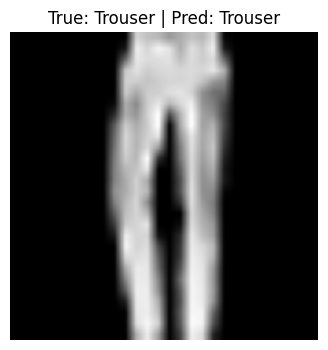

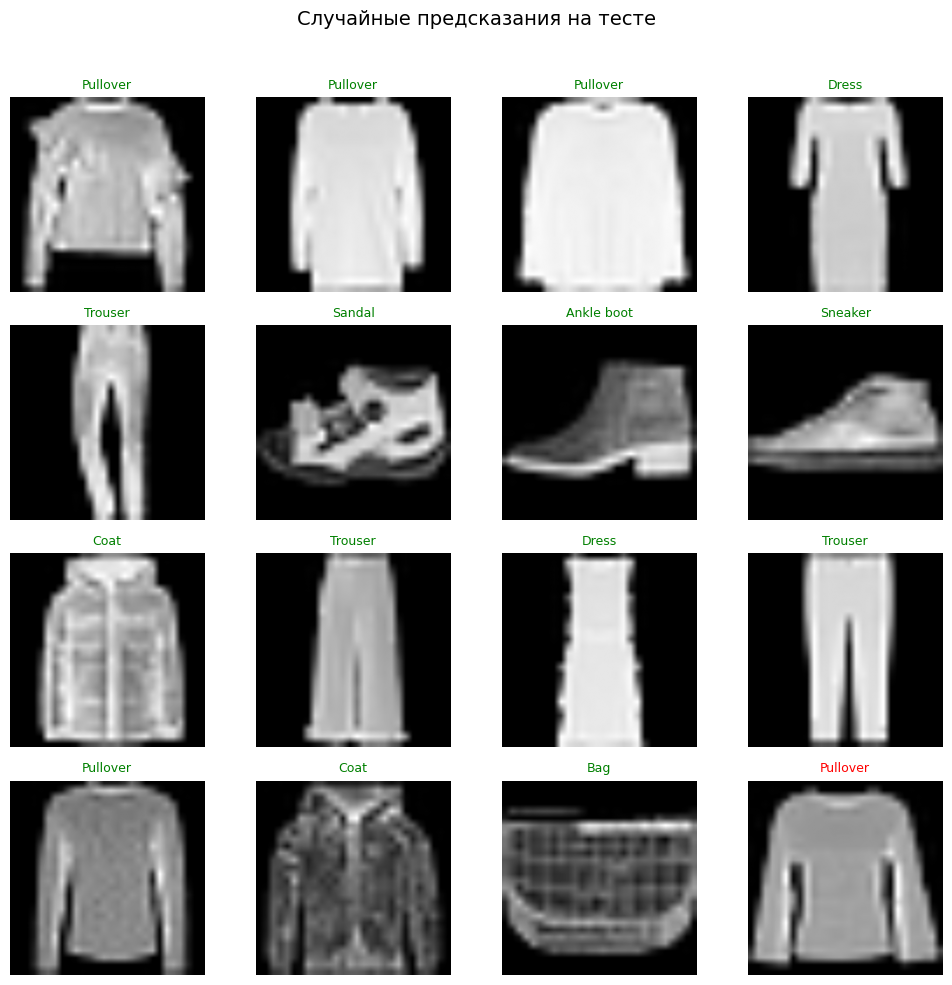

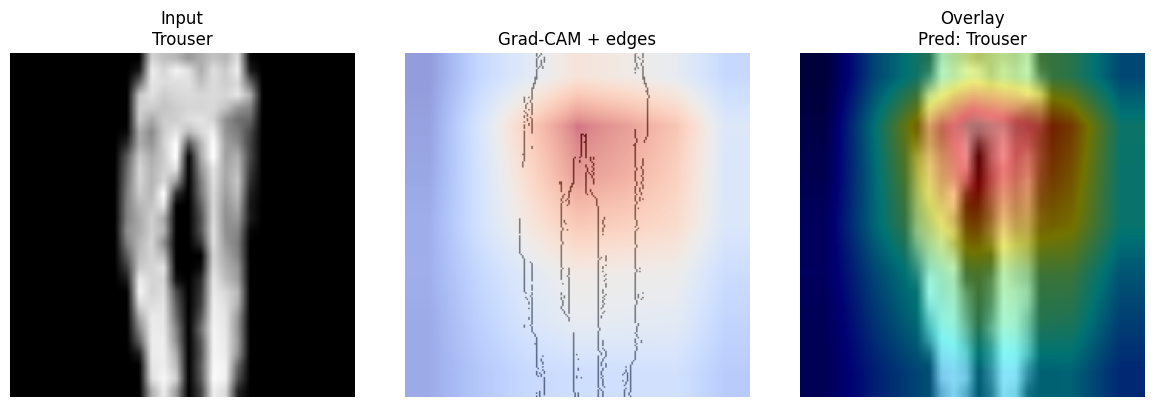

In [19]:
def load_and_preprocess_image(image_path: Path, transform=None):
    image = Image.open(image_path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    image_np = np.array(image, dtype=np.uint8)
    if transform is None:
        transform = get_eval_transforms()
    return transform(image=image_np)["image"].unsqueeze(0)


def test_on_real_data(model, image_paths, device):
    model.eval()
    transform = get_eval_transforms()
    predictions = []
    with torch.no_grad():
        for path in image_paths:
            predicted_class = model(load_and_preprocess_image(path, transform).to(device)).argmax(dim=1).item()
            predictions.append((str(path), CLASS_NAMES[predicted_class]))
            print(f"Image {path}: Predicted Class {CLASS_NAMES[predicted_class]}")
    return predictions


visualize_prediction(model, test_dataset, index=1, device=DEVICE)
show_prediction_grid(model, test_dataset, DEVICE)
visualize_gradcam(model, test_dataset, index=1, device=DEVICE)

if writer is not None:
    writer.close()

